# [실습 7-1] 붓꽃 분류 — 분류기 4종 비교

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 40~50분 (CPU 충분) |
| 본문 연계 | 7.6 (알고리즘 5계열 학습 후 종합) |
| 선수 실습 | [실습 6-1] (분할·교차검증 개념 재사용) |
| 준비 | 부록 B.1·B.3 참고 |

6장에서 배운 워크플로 체크리스트(6.5) 그대로 —
**문제 정의 → 데이터 준비·분할 → 학습 → 평가 → 비교·선택**의
전 과정을 분류기 4종으로 완주한다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/tbgoodlife/ai-labs.git
# %cd ai-labs
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch07/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from utils import plot_style, viz

plot_style.apply()              # 도해 스타일 킷 적용
print("Python", platform.python_version())
print("NumPy", np.__version__,
      "/ scikit-learn", sklearn.__version__)

Python 3.12.6
NumPy 2.4.6 / scikit-learn 1.9.0


### [셀 1] 데이터 준비와 분할 — 워크플로 1·2단계 📖

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
# 6.2.1에서 소개한 그 데이터 — 특징 2개만 사용해
# 결정 경계를 눈으로 볼 수 있게 한다(꽃잎 길이·너비)
X = iris.data[:, 2:4]
y = iris.target
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
print(f"훈련 {len(X_tr)}건 / 평가 {len(X_te)}건, "
      f"클래스 {[str(c) for c in iris.target_names]}")

훈련 105건 / 평가 45건, 클래스 ['setosa', 'versicolor', 'virginica']


**핵심 포인트**
- 문제 정의(워크플로 1단계): "꽃잎 치수 2개로 품종 3종을 분류한다" — 정답 데이터가 있으므로 **지도학습·분류** 문제다.
- `stratify=y`: 분할 후에도 세 품종의 비율이 유지되도록 한다(6장 분할 원칙의 실전 옵션).

기대 출력: `훈련 105건 / 평가 45건`

### [셀 2] 분류기 4종 학습 — 워크플로 3단계 📖

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {
    "로지스틱 회귀": LogisticRegression(),
    "kNN (k=5)": KNeighborsClassifier(5),
    "결정 트리": DecisionTreeClassifier(
        random_state=42),
    "SVM (RBF)": SVC(kernel="rbf"),
}
for name, model in models.items():
    model.fit(X_tr, y_tr)
    acc = model.score(X_te, y_te)
    print(f"{name:<10} 평가 정확도 {acc:.3f}")

로지스틱 회귀    평가 정확도 0.933


kNN (k=5)  평가 정확도 0.933
결정 트리      평가 정확도 0.933
SVM (RBF)  평가 정확도 0.933


**핵심 포인트**
- scikit-learn의 통일된 문법: 어떤 알고리즘이든 `fit()`으로 배우고 `score()`로 채점한다 — 그래서 4종 비교가 루프 하나로 끝난다.
- 정확도가 비슷해 보인다 — 하지만 **어떻게** 나누는지는 전혀 다르다. 다음 셀에서 확인한다.

실패 시 대처: 수렴 경고가 뜨면 `LogisticRegression(max_iter=500)`으로 여유를 준다.

### [셀 3] 결정 경계 4분할 시각화 — "같은 데이터, 다른 공구" 📖

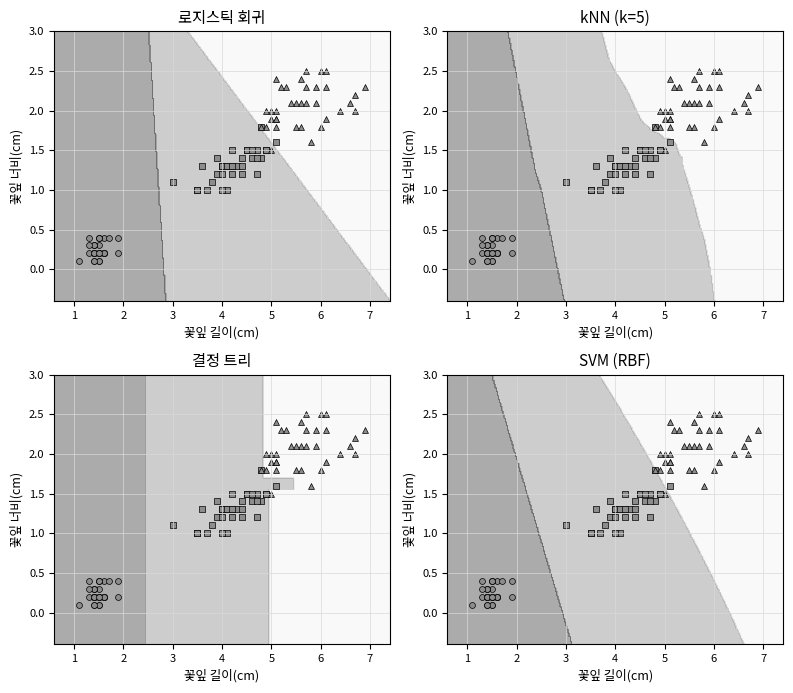

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
for ax, (name, model) in zip(axes.ravel(),
                             models.items()):
    viz.plot_decision_boundary(
        model, X_tr, y_tr, ax=ax, title=name)
    ax.set_xlabel("꽃잎 길이(cm)")
    ax.set_ylabel("꽃잎 너비(cm)")
plt.tight_layout()
plt.show()

**핵심 포인트**
- **로지스틱 회귀**: 곧은 경계 / **kNN**: 이웃을 따라 굽이치는 경계 / **결정 트리**: 축에 평행한 계단 경계(질문이 "길이 > 2.5?" 꼴이므로) / **SVM(RBF)**: 매끄러운 곡선 경계.
- 본문 [그림 7-x]와 같은 구도다. 그리기 함수는 `utils/viz.py`의 `plot_decision_boundary()` — 25줄 상한을 넘어 유틸로 분리했다(코드 정책 ③). 9장 XOR 실습에서 재사용된다.

### [셀 4] 교차검증 비교표 — 워크플로 4·5단계 📖

In [5]:
from sklearn.model_selection import cross_val_score

print(f"{'분류기':<12}{'교차검증 평균':>10}{'표준편차':>8}")
for name, model in models.items():
    scores = cross_val_score(model, X_tr, y_tr, cv=5)
    print(f"{name:<12}{scores.mean():>12.3f}"
          f"{scores.std():>10.3f}")

분류기            교차검증 평균    표준편차
로지스틱 회귀            0.971     0.023
kNN (k=5)          0.971     0.023
결정 트리              0.952     0.030
SVM (RBF)          0.971     0.023


**핵심 포인트**
- 단일 분할 점수([셀 2])보다 5겹 평균이 믿을 만하다 — 6장 교차검증의 실전 사용.
- 네 분류기 모두 평균 0.9 이상이고 차이는 표준편차 범위 안 — **"잘 정제된 쉬운 데이터에서는 어떤 공구든 통한다."** 그러면 무엇으로 고르나? 해석 가능성·학습 속도·데이터 특성으로 고른다(7.7 선택 가이드).

실패 시 대처: 표가 지면과 소수점 셋째 자리에서 다르면 scikit-learn 버전을 [준비] 셀 출력과 대조한다.

### [보조 2] 하이퍼파라미터가 경계를 바꾼다

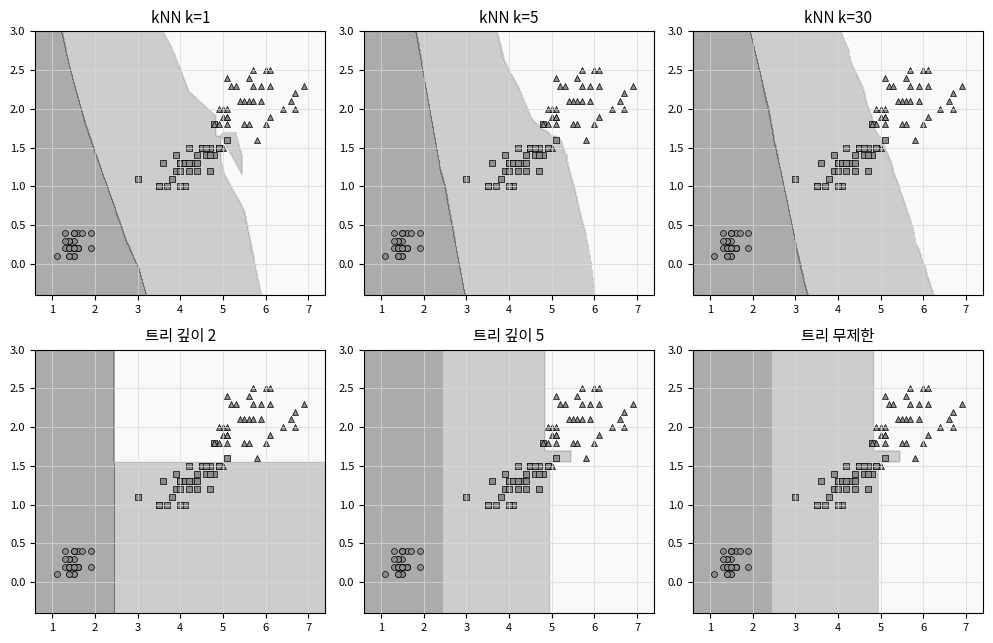

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6.5))
variants = [
    ("kNN k=1", KNeighborsClassifier(1)),
    ("kNN k=5", KNeighborsClassifier(5)),
    ("kNN k=30", KNeighborsClassifier(30)),
    ("트리 깊이 2", DecisionTreeClassifier(
        max_depth=2, random_state=42)),
    ("트리 깊이 5", DecisionTreeClassifier(
        max_depth=5, random_state=42)),
    ("트리 무제한", DecisionTreeClassifier(
        random_state=42)),
]
for ax, (name, model) in zip(axes.ravel(), variants):
    model.fit(X_tr, y_tr)
    viz.plot_decision_boundary(model, X_tr, y_tr,
                               ax=ax, title=name)
plt.tight_layout()
plt.show()

k=1과 깊이 무제한은 훈련 점 하나하나에 반응하는 **과적합형 경계**(6장 재소환), k=30과 깊이 2는 뭉툭한 **과소적합형 경계**다 — 하이퍼파라미터가 곧 복잡도 손잡이임을 확인하자. 안전한 시작값: kNN은 k=5, 트리는 깊이 3~5.

### [심화 1] 새 분류기 추가와 비교표 갱신 (연습문제 심화 직결)

In [7]:
from sklearn.ensemble import RandomForestClassifier

# TODO 1: 랜덤 포레스트를 models에 추가하고
#         [셀 2]~[셀 4]를 재실행해 비교표를 갱신하자.
models["랜덤 포레스트"] = RandomForestClassifier(
    n_estimators=100, random_state=42)

# TODO 2: GridSearchCV로 SVM의 C·gamma를 탐색해
#         기본값 대비 개선 폭을 보고해 보자.
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(
    SVC(kernel="rbf"),
    {"C": [0.1, 1, 10], "gamma": [0.1, 1, 10]}, cv=5)
grid.fit(X_tr, y_tr)
print("최적 조합:", grid.best_params_,
      f"/ 교차검증 {grid.best_score_:.3f}")

최적 조합: {'C': 0.1, 'gamma': 1} / 교차검증 0.971


---
## 마무리

- 워크플로 체크리스트(6.5)대로 처음부터 끝까지: 문제 정의 → 분할 → 4종 학습 → 교차검증 평가 → 비교·선택.
- 같은 데이터라도 알고리즘마다 경계의 **모양**이 다르다 — 직선/굽이/계단/곡선은 각 알고리즘의 가정(원리)이 그림이 된 것이다.
- 정확도가 비슷할 때의 선택 기준은 해석 가능성·속도·데이터 규모다(7.7) — 대출 심사라면 무엇을 고르겠는가(연습문제 심화).

**연습문제 연계**: [심화] 새 분류기 추가·하이퍼파라미터 탐색 후 비교표 갱신은 [심화 1] 뼈대에서 수행한다.

**다음 실습**: [실습 8-1] k-평균 고객 세분화 (`ch08/lab-08-01_kmeans-customers.ipynb`)